### Imports

In [150]:
import os
import torch
import random
import numpy as np
import torch.nn as nn
from collections import deque

import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from matplotlib.colors import to_rgba

from MyoElbowPose2D6M import MyoElbowPose2D6MFixed

### Constants

In [151]:
# --- Simulation parameters ---
dt, tau_n, tau_m = 0.01, 0.02, 0.05

# --- Neural network parameters ---
n_s, n_m1, n_muscles, n_inputs = 200, 200, 6, 10

# --- Feedback gains ---
G_p, G_d, G_f = 1.0, 1.0, 1.0

# --- Reflex parameters ---
G_aff = torch.tensor([1.0, 0.1, 0.01, 0.0001])
G_s_low, G_s_high = 0.8, 1.9

reflex_delay = int(0.02 / dt)

# --- Activation and feedback delay ---
activation_delay_steps = int(0.03 / dt)
feedback_delay_steps = int(0.04 / dt) 

# --- Moment arm matrix  ---
M_m = torch.tensor([
    [ 0.10,  0.00],       # Muscle 0: Mono Shoulder Flexor (Pure Up/Left)
    [-0.10,  0.00],       # Muscle 1: Mono Shoulder Extensor (Pure Down/Right)
    [ 0.00,  0.10],       # Muscle 2: Mono Elbow Flexor (Pure Down/Left)
    [ 0.00, -0.10],       # Muscle 3: Mono Elbow Extensor (Pure Up/Right)
    [ 0.08,  0.08],       # Muscle 4: Bi-articular Flexor (Synergy)
    [-0.08, -0.08]        # Muscle 5: Bi-articular Extensor (Synergy)
], dtype=torch.float32)

# --- Penalty coefficients ---
alpha, beta, gamma = 0.0001, 0.001, 0.5

# --- External loads ---
background_load_low, background_load_high, perturbation_load = 0.1, 0.55, 0.25

# --- Time parameters and steps ---
Tb, Tsb, Tp, Tsp, T = 0.20, 1.00, 1.50, 2.50, 3.00
Tb_step, Tsb_step, Tp_step, Tsp_step, T_step = int(Tb / dt), int(Tsb / dt), int(Tp / dt), int(Tsp / dt), int(T / dt)

# --- Perturbation directions ---
perturbation_directions = {
    "Right": np.array([1.0, 0.0]), "Left": np.array([-1.0, 0.0]),
    "Up": np.array([0.0, 1.0]), "Down": np.array([0.0, -1.0]),
    "Up-Right": np.array([0.707, 0.707]), "Up-Left": np.array([-0.707, 0.707]),
    "Down-Left": np.array([-0.707, -0.707]), "Down-Right": np.array([0.707, -0.707])}

# --- Arm segment lengths ---
l1, l2 = 0.12, 0.10

### Neural Limb Controller

In [152]:
class NeuralLimbController(nn.Module):
    def __init__(self, n_inputs, n_outputs=n_muscles):
        super().__init__()
        
        # Sensory layer (200 units)
        self.w_sr = nn.Parameter(torch.empty(n_s, n_s))
        self.w_si = nn.Parameter(torch.empty(n_s, n_inputs))
        self.b_s = nn.Parameter(torch.zeros(n_s))

        # M1 layer (200 units)
        self.w_mr = nn.Parameter(torch.empty(n_m1, n_m1))
        self.w_mi = nn.Parameter(torch.empty(n_m1, n_s))
        self.b_m = nn.Parameter(torch.zeros(n_m1))

        # Muscle activation layer
        self.w_act = nn.Parameter(torch.empty(n_muscles, n_m1))
        
        # --- INTERNAL INITIALIZATION ---
        self._initialize_stable()

        # Internal state variables
        self.y_s = torch.zeros(n_s)
        self.y_m = torch.zeros(n_m1)
        self.y_act = torch.zeros(n_muscles)

    def _initialize_stable(self):
        """
        Internal initialization replacing the external functions.
        Uses Orthogonal for RNNs and 'Soft Start' for muscles.
        """
        # 1. Orthogonal Init for Recurrent Weights
        nn.init.orthogonal_(self.w_sr)
        nn.init.orthogonal_(self.w_mr)
        
        # 2. Xavier for Input Weights
        nn.init.xavier_uniform_(self.w_si)
        nn.init.xavier_uniform_(self.w_mi)
        
        # 3. Soft Start for Muscle Output
        nn.init.xavier_uniform_(self.w_act)
    
    def reset_states(self):
        """Reset the internal states."""
        self.y_s.zero_()
        self.y_m.zero_()
        self.y_act.zero_()

    def reset_weights(self):
        """Reinitialize weights safely."""
        self._initialize_stable() 

    def neural_activation_step(self, y_t, u_t):
        return (1 - (dt / tau_n)) * y_t + (dt / tau_n) * torch.tanh(u_t)
    
    def muscle_activation_step(self, y_act_t, u_act_t):
        """Discretized muscle activation dynamics."""
        # Change torch.relu to F.softplus to prevent "Dead Neurons"
        # beta=5 makes it close to ReLU but smooth
        activation = torch.nn.functional.softplus(u_act_t, beta=5) 
        return (1 - (dt / tau_m)) * y_act_t + (dt / tau_m) * activation

    def forward_step(self, u_fb_cortical, u_spinal_reflex, y_s_prev, y_m_prev, y_act_prev):
        """Perform a single forward step of the neural controller."""
        
        # Sensory layer
        # Use y_s_prev consistently for both matrix mult AND integration
        u_s = self.w_sr @ y_s_prev + self.w_si @ u_fb_cortical + self.b_s
        self.y_s = self.neural_activation_step(y_s_prev, u_s) 

        # Motor layer
        # Use y_m_prev consistently
        u_m = self.w_mr @ y_m_prev + self.w_mi @ self.y_s + self.b_m
        self.y_m = self.neural_activation_step(y_m_prev, u_m)

        # Muscle activation layer
        u_act = self.w_act @ self.y_m + u_spinal_reflex
        self.y_act = self.muscle_activation_step(y_act_prev, u_act)

        return self.y_act

### Hill-type muscle model equations

In [153]:
class MuscleConstants:
    """Physiological constants for muscle dynamics."""
    F_MAX = 120.0             # Maximum isometric force (N)
    L_OPT = 1.0               # Optimal fiber length (normalized)
    V_MAX = 10.0              # Max shortening velocity (L_opt/s)

    # Shortening coefficients (Hill's Equation)
    A_HILL = 0.25             
    B_HILL = A_HILL * V_MAX   

    # Lengthening coefficients
    K_ECC = 0.15              # Eccentric shape factor
    F_MAX_ECC = 1.4           # Max eccentric force
    
class ForceLength:
    """Computes the force-length relationship (Active + Passive)."""
    
    @staticmethod
    def compute(L_m, L_opt=MuscleConstants.L_OPT, width_factor=0.4, passive_scale=0.01):
        """Calculates active (bell-curve) and passive (spring) force components."""
        # Active Component: Gaussian bell curve around optimal length
        FL_active = torch.exp(-((L_m - L_opt) / width_factor).pow(2))
        
        # Passive Component: Exponential spring for stretching
        strain = (L_m - L_opt) / L_opt
        k_pe = 4.0 
        FL_passive = passive_scale * (torch.exp(k_pe * strain) - 1.0)
        
        # Ensure passive force is non-negative
        return FL_active, torch.clamp(FL_passive, min=0.0)

class ForceVelocity:
    """Computes the force-velocity relationship (Hill's Equation)."""
    
    @staticmethod
    def compute(dLm_dt, V_max=MuscleConstants.V_MAX, A_hill=MuscleConstants.A_HILL, 
                B_hill=MuscleConstants.B_HILL, F_max_ecc=MuscleConstants.F_MAX_ECC, 
                K_ecc=MuscleConstants.K_ECC):
        """Calculates FV scaling based on muscle velocity (dLm/dt)."""
        epsilon = 1e-6
        
        # --- FIX: CLAMP VELOCITY ---
        # Prevent velocity from exceeding V_max (which causes div by zero)
        # We clamp it to -0.95 * V_MAX to be safe.
        dLm_dt_clamped = torch.clamp(dLm_dt, min=-0.95 * V_max, max=V_max)

        # Shortening (dLm_dt <= 0)
        FV_shortening = (B_hill - dLm_dt_clamped) / (B_hill + A_hill * dLm_dt_clamped + epsilon)
        
        # Lengthening (dLm_dt > 0)
        FV_lengthening = (F_max_ecc - 1.0) * (1.0 - torch.exp(-K_ecc * dLm_dt_clamped)) + 1.0
        
        return torch.where(dLm_dt_clamped <= 0.0, FV_shortening, FV_lengthening)

### Helper functions

In [154]:
# --- Initialization & Setup ---

def set_seed(seed=42):
    """Sets random seeds for reproducibility (Python, NumPy, PyTorch)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)

def reset_environment_and_controller(env, controller, target_qpos, offset_x, offset_y):
    """Resets environment/controller and returns initial observation."""
    controller.reset_states()
    obs, _ = env.reset(target_qpos=target_qpos, offset=(offset_x, offset_y))
    return obs

def initialize_epoch_params(perturbation_directions, bg_low, bg_high, G_s_low, G_s_high):
    """Selects random load conditions and perturbation direction for the epoch."""
    # Randomize Load Condition
    background_load = random.choice([bg_low, bg_high])
    load_condition = "High" if background_load == bg_high else "Low"
    G_s = G_s_high if background_load == bg_high else G_s_low
    
    # Randomize Direction
    idx = random.randint(0, len(perturbation_directions) - 1)
    dir_name = list(perturbation_directions.keys())[idx]
    
    return background_load, load_condition, G_s, idx, dir_name

def initialize_buffers(feedback_delay, reflex_delay, init_qpos, init_qvel, init_aff):
    """Creates history buffers for delayed feedback."""
    cortical = deque([ (init_qpos, init_qvel) for _ in range(feedback_delay) ], maxlen=feedback_delay)
    spinal = deque([ init_aff for _ in range(reflex_delay) ], maxlen=reflex_delay)
    return cortical, spinal

def update_buffers(cortical, spinal, qpos, qvel, aff):
    """Pushes current state into delay buffers."""
    cortical.append((qpos, qvel))
    spinal.append(aff)


# --- Biomechanics & Math Helpers ---

def compute_muscle_lengths(theta_s, theta_e, theta_s_ref, theta_e_ref, M_m):
    """Calculates muscle length changes via moment arm matrix."""
    delta_theta = torch.tensor([theta_s - theta_s_ref, theta_e - theta_e_ref], dtype=torch.float32)
    return 1.0 + (-M_m @ delta_theta) # Optimal length (1.0) + deviation

def compute_jacobian(theta_s, theta_e, l1, l2):
    """Analytic Jacobian for 2-link planar arm."""
    s1, c1 = np.sin(theta_s), np.cos(theta_s)
    s12, c12 = np.sin(theta_s + theta_e), np.cos(theta_s + theta_e)
    return np.array([[-l1*s1 - l2*s12, -l2*s12], 
                     [ l1*c1 + l2*c12,  l2*c12]])

def forward_kinematics_torch(qpos, l1, l2):
    """Computes (x, y) from joint angles (Tensor safe)."""
    ts, te = qpos[..., 0], qpos[..., 1]
    x = l1 * torch.cos(ts) + l2 * torch.cos(ts + te)
    y = l1 * torch.sin(ts) + l2 * torch.sin(ts + te)
    return x, y

def compute_pose_error(obs, target_qpos, l1, l2, off_x, off_y):
    """Calculates Euclidean distance from end-effector to target."""
    x = l1 * np.cos(obs[0]) + l2 * np.cos(obs[0] + obs[2]) - off_x
    y = l1 * np.sin(obs[0]) + l2 * np.sin(obs[0] + obs[2]) - off_y
    dist = np.sqrt((target_qpos[0] - x)**2 + (target_qpos[1] - y)**2)
    return dist, (x, y)

def compute_desired_force(step, Tb, Tp, Tsp, bg_load, p_load, p_dirs, dir_name):
    """Returns external force vector based on simulation phase."""
    force_mag = 0.0
    if Tb <= step < Tp: force_mag = bg_load
    elif Tp <= step < Tsp: force_mag = bg_load + p_load
    elif step >= Tsp: force_mag = bg_load
    return force_mag * p_dirs[dir_name]


# --- State Updates & Control ---

def update_muscle_kinematics(qpos, qvel, theta_ref, L_m_init, M_m, dt, vel_Lm_prev, acc_Lm_prev):
    """Updates muscle lengths using differentiable tensors to preserve the gradient chain."""
    # Ensure inputs are tensors
    if not isinstance(theta_ref, torch.Tensor): 
        theta_ref = torch.tensor(theta_ref, dtype=torch.float32)
    
    # 1. Calculate Joint Displacement (Differentiable)
    # qpos is [batch, 2] or [2], theta_ref is [2]
    delta_theta = qpos - theta_ref
    
    # 2. Calculate Muscle Length (Differentiable)
    # M_m is [6, 2]. Result is [6]
    # We use matrix multiplication (@)
    length_change = (-M_m @ delta_theta)
    new_L_m = L_m_init + length_change
    
    # 3. Calculate Muscle Velocity (Differentiable)
    dLm_dt = (-M_m @ qvel)
    
    # 4. Accelerations (Finite difference is fine as long as inputs are tensors)
    # Note: These don't need to be fully differentiable for the primary feedback loop
    # but we keep them as tensors for consistency.
    new_acc = (dLm_dt - vel_Lm_prev) / dt
    new_jerk = (new_acc - acc_Lm_prev) / dt
    
    # Return all as tensors
    return new_L_m, length_change, dLm_dt, new_acc, new_jerk, dLm_dt

def compute_feedback_signals(obs, d_qpos, d_qvel, d_aff, target, G_p, G_d, G_f, F_m):
    """
    Assembles cortical (LLR) and spinal (SLR) feedback vectors with Normalization.
    Crucial to prevent exploding gradients.
    """
    # 1. Normalize Position Error (approx range 0.5 rad -> 1.0)
    # We detach target because we don't want the network to move the target, just the arm.
    pos_error = d_qpos - target.detach()
    norm_pos_error = pos_error / 0.5 
    
    # 2. Normalize Velocity (approx max 10.0 rad/s -> 1.0)
    norm_vel = d_qvel / 10.0
    
    # 3. Normalize Force (approx max 60.0 N -> 1.0)
    # This is the most critical one. 60.0 is huge for a neural net input.
    norm_force = F_m / 60.0
    
    u_cortical = torch.cat([
        G_p * norm_pos_error, 
        G_d * norm_vel, 
        G_f * norm_force
    ], dim=0)
    
    # Normalize Afferents if necessary (Spinal input)
    # If G_aff produces values > 1.0, scale them here too.
    # For now, we assume G_aff are small enough or handled by G_s.
    
    return u_cortical, d_aff


# --- Loss & Optimization ---
    
def get_cost_weights(epoch, total_epochs):
    progress = epoch / total_epochs
    
    # Phase 1: Stability (High damping/force penalty to stop explosions)
    if progress < 0.2:
        return 0.0001, 0.1, 1.0  
    
    # Phase 2: Learning the Task (Focus on kinematics)
    elif progress < 0.6:
        return 0.0001, 0.05, 2.0 
        
    # Phase 3: The "Biological" Phase (Matching the Paper)
    else:
        return 0.0001, 0.01, 0.5
    
def compute_kinematic_penalty_radians(qpos, qvel, target_qpos):
    """
    Calculates the kinematic cost using the formula from the paper:
    Cost = ||theta - theta_g||^2 + 0.5 * ||theta_dot||^2
    
    """
    # qpos and target_qpos are [shoulder_rad, elbow_rad]
    angle_error = qpos - target_qpos
    
    # Square of the Euclidean norm of the angle error
    pos_cost = torch.sum(angle_error.pow(2))
    
    # Square of the Euclidean norm of the angular velocity, scaled by 0.5
    vel_cost = 0.5 * torch.sum(qvel.pow(2))
    
    return pos_cost + vel_cost

def accumulate_costs(controller, F_m, qpos, qvel, target_qpos, 
                     loss_n, loss_f, loss_k, Tsb_step, Tp_step, Tsp_step, step):
    """
    Accumulates neural, force, and kinematic costs per the paper's 
    composite cost function J. [cite: 508]
    """
    # 1. Neural Energy Cost (alpha): Penalize sensory and motor RNN activity [cite: 508, 509]
    loss_n += (controller.y_s.pow(2).sum() + controller.y_m.pow(2).sum())
    
    # 2. Muscle Force Cost (beta): Penalize squared muscle force [cite: 508, 509]
    # Note: Using F_m (force) or y_act (activation) is consistent with metabolic energy costs
    loss_f += F_m.pow(2).sum()

    # 3. Kinematic Cost (gamma): Penalize joint deviation and velocity [cite: 512, 514, 527]
    # In the paper, J_b (background) and J_p (perturbation) are specific to steady-state windows.
    # We apply the penalty during the 'hold' phases defined in the method[cite: 529, 531].
    
    # Define the "Surprise" window where the monkey shouldn't be penalized for being bumped
    grace_period_steps = int(0.08 / dt) # 80ms grace period [cite: 79]
    
    # J_b logic: steady-state realization of background load [cite: 529]
    is_background_steady = (Tsb_step <= step < Tp_step)
    
    # J_p logic: steady-state realization of perturbation load [cite: 529]
    is_perturbation_steady = (step >= Tp_step + grace_period_steps)
    
    if is_background_steady or is_perturbation_steady:
        loss_k += compute_kinematic_penalty_radians(qpos, qvel, target_qpos)

    return loss_n, loss_f, loss_k

def normalize_and_compute_total_loss(l_n, l_f, l_k, alpha, beta, gamma, steps):
    """Computes weighted average loss for backpropagation."""
    return alpha*(l_n/steps) + beta*(l_f/steps) + gamma*(l_k/steps)


# --- Physics Engine ---

def differentiable_physics_step(qpos, qvel, normalized_muscle_force, external_torque, M_m, inertia=0.1, damping=0.4, dt=0.01):
    # Ensure this uses the EXACT SAME M_m and inertia as the environment
    muscle_forces = normalized_muscle_force * 60.0
    
    # Internal Torque from muscles
    internal_torque = M_m.T @ muscle_forces
    
    # Total Torque
    total_torque = internal_torque + external_torque
    
    # Dynamics
    joint_accel = (total_torque - damping * qvel) / inertia
    
    new_qvel = torch.clamp(qvel + joint_accel * dt, -20, 20)
    new_qpos = qpos + new_qvel * dt
    
    return new_qpos, new_qvel

### Training Loop

In [155]:
# --- GLOBAL CONFIGURATION ---
num_epochs = 500

# --- INITIALIZATION ---
set_seed(42)
env = MyoElbowPose2D6MFixed()
controller = NeuralLimbController(n_inputs=n_inputs, n_outputs=n_muscles)

optimizer = torch.optim.Adam(controller.parameters(), lr=1e-4, weight_decay=1e-5)
torch.nn.utils.clip_grad_norm_(controller.parameters(), max_norm=1.0)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

if not isinstance(M_m, torch.Tensor):
    M_m_tensor = torch.tensor(M_m, dtype=torch.float32)
else:
    M_m_tensor = M_m.clone().detach().float()

# Initialize Storage
epoch_metadata = []
epoch_qpos_over_time = []
epoch_neural_activity = [] 
epoch_costs_over_time = []
target_results = {i: {"pose_errors": [], "rewards": [], "costs": {key: [] for key in ["neural", "force", "kinematic", "total"]}} for i in range(len(perturbation_directions))}


# --- TRAINING LOOP ---
for epoch in range(num_epochs):
    # Detach hidden states from previous epoch to stop infinite backprop history
    controller.y_s = controller.y_s.detach()
    controller.y_m = controller.y_m.detach()
    controller.y_act = controller.y_act.detach()

    # 0. Update Costs for this Epoch
    alpha, beta, gamma = get_cost_weights(epoch, num_epochs)

    # 1. Setup Targets
    base_qs, base_qe = np.radians(35), np.radians(90)
    base_x = l1 * np.cos(base_qs) + l2 * np.cos(base_qs + base_qe)
    base_y = l1 * np.sin(base_qs) + l2 * np.sin(base_qs + base_qe)
    offset_x, offset_y = base_x, base_y

    target_qpos = (base_qs, base_qe)
    target_qpos_tensor = torch.tensor([base_qs, base_qe], dtype=torch.float32) # Fixed variable name

    # 2. Epoch Params
    background_load, load_condition, G_s, perturbation_idx, direction_name = initialize_epoch_params(
        perturbation_directions, background_load_low, background_load_high, G_s_low, G_s_high
    )

    # 3. Reset Env
    # Note: We still use the env reset to get the clean starting state, 
    # but we immediately wrap it in tensors for the loop.
    obs_numpy = reset_environment_and_controller(env, controller, target_qpos, offset_x, offset_y)
    
    # Force Perfect Start
    env.set_joint_angles([base_qs, 0.0, base_qe, 0.0])
    obs_numpy = env._get_obs()

    # Log metadata
    epoch_metadata.append({"load": load_condition, "direction": direction_name})
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}")

    # 4. Buffers & Init
    activation_buffer = [torch.zeros(n_muscles) for _ in range(activation_delay_steps)]
    delayed_activations = activation_buffer[0]
    previous_act = None
    loss_neural_accum, loss_force_accum, loss_kinematic_accum = 0, 0, 0
    pose_errors, rewards, qpos_over_time = [], [], []
    epoch_costs = {key: [] for key in ["neural", "force", "kinematic", "total"]}
    trial_neural_history = []

    # Init Muscle Lengths
    theta_s_ref, theta_e_ref = obs_numpy[0], obs_numpy[2]
    # We detach initialization values because we don't need gradients for t=-1
    initial_lengths = compute_muscle_lengths(theta_s_ref, theta_e_ref, theta_s_ref, theta_e_ref, M_m)
    L_m_initial = initial_lengths.clone().detach() # Constant ref
    
    delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m = [torch.zeros(n_muscles) for _ in range(4)]
    
    # CRITICAL: Initialize Tensors that will carry the gradient
    current_qpos = torch.tensor([obs_numpy[0], obs_numpy[2]], dtype=torch.float32)
    current_qvel = torch.tensor([obs_numpy[1], obs_numpy[3]], dtype=torch.float32)
    
    initial_x_m = torch.zeros((n_muscles, 4), dtype=torch.float32)
    initial_aff = (G_aff @ initial_x_m.T).flatten()
    
    # Initialize buffers with Tensors
    cortical_buffer, spinal_buffer = initialize_buffers(
        feedback_delay_steps, reflex_delay, current_qpos, current_qvel, initial_aff
    )

# --- SIMULATION ---
    for step in range(T_step):
        # A. Targets & Forces
        desired_force = compute_desired_force(step, Tb_step, Tp_step, Tsp_step, background_load, perturbation_load, perturbation_directions, direction_name)

        # B. Physics Setup
        theta_s, theta_e = current_qpos[0], current_qpos[1]
        
        # 1. Use the current angles for the Jacobian
        J = compute_jacobian(theta_s.detach().item(), theta_e.detach().item(), l1, l2)
        
        # 2. APPLY THE SIGN CORRECTION
        tau = -(J.T @ desired_force) 
        tau_tensor = torch.tensor(tau, dtype=torch.float32)
        
        # 3. Inform the environment
        env.set_external_torque(tau)
        
        # --- CRITICAL FIX: Tare Sensors at Perturbation Onset ---
        # [cite_start]The paper defines afferent feedback (x_aff) as the deviation from the "initial state". [cite: 463]
        # To allow the spinal reflex to react specifically to the perturbation (and not the background hold),
        # we reset the reference state at the moment the perturbation is applied (Tp).
        if step == Tp_step:
            # 1. Capture the current "Steady State" posture
            theta_s_ref, theta_e_ref = current_qpos[0].item(), current_qpos[1].item()
            
            # 2. Recalculate optimal muscle lengths for this new posture
            # We assume "0 stretch" at this exact moment.
            # We detach because this becomes our new constant reference point.
            ref_lengths = compute_muscle_lengths(
                theta_s_ref, theta_e_ref, 
                theta_s_ref, theta_e_ref, # Delta is 0
                M_m_tensor
            )
            L_m_initial = ref_lengths.clone().detach()

        # C. Update Muscle Kinematics
        # We pass the (potentially updated) theta_ref and L_m_initial.
        L_m, delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m, dLm_dt = update_muscle_kinematics(
            qpos=current_qpos, 
            qvel=current_qvel,
            theta_ref=torch.tensor([theta_s_ref, theta_e_ref]), # Uses updated ref if step >= Tp
            L_m_init=L_m_initial,                               # Uses updated ref if step >= Tp
            M_m=M_m_tensor, 
            dt=dt,
            vel_Lm_prev=velocity_L_m,          
            acc_Lm_prev=acceleration_L_m       
        )
        
        x_m = torch.stack([delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m], dim=1)
        current_aff = (G_aff @ x_m.T).flatten()

        # D. Muscle Dynamics
        FL_active, FL_passive = ForceLength.compute(L_m)
        # Calculate FV for the physics (Forward pass), but DETACH it from the gradient (Backward pass).
        # This stops the optimizer from trying to "hack" the velocity curve, which causes explosions.
        FV = ForceVelocity.compute(dLm_dt.squeeze()).detach() 
        F_m = (delayed_activations * FL_active * FV) + FL_passive

        # E. Control Step
        # Pop from buffer (these contain gradients from t - delay)
        delayed_qpos, delayed_qvel = cortical_buffer[0]
        delayed_aff = spinal_buffer[0]
        
        u_fb_cortical, u_spinal = compute_feedback_signals(
            None, # obs is removed
            delayed_qpos, delayed_qvel, delayed_aff, 
            target_qpos_tensor, G_p, G_d, G_f, F_m
        )

        delayed_aff = spinal_buffer[0] 
        u_spinal_reflex = (G_s * delayed_aff).detach()

        muscle_activations = controller.forward_step(
            u_fb_cortical, u_spinal_reflex, controller.y_s, controller.y_m, controller.y_act
        )
        trial_neural_history.append(controller.y_m.abs().mean().item())

        # CRITICAL: Push current Tensors (with gradients) into buffer
        update_buffers(cortical_buffer, spinal_buffer, current_qpos, current_qvel, current_aff)
        
        delayed_activations = activation_buffer.pop(0)
        activation_buffer.append(muscle_activations)
            
        # F. Differentiable Physics Step
        next_qpos, next_qvel = differentiable_physics_step(current_qpos, current_qvel, F_m, tau_tensor, M_m_tensor)
        
        # G. Loss Accumulation
        loss_neural_accum, loss_force_accum, loss_kinematic_accum = accumulate_costs(
            controller, F_m, next_qpos, next_qvel, target_qpos_tensor, 
            loss_neural_accum, loss_force_accum, loss_kinematic_accum, 
            Tsb_step, Tp_step, Tsp_step, step
        )
        
        # Logging (Visuals only - Detach here!)
        obs_display = np.array([next_qpos[0].item(), next_qvel[0].item(), next_qpos[1].item(), next_qvel[1].item()])
        pose_error, (x, y) = compute_pose_error(obs_display, (base_qs, base_qe), l1, l2, offset_x, offset_y)
        pose_errors.append(pose_error)
        qpos_over_time.append((x, y))

        # CRITICAL: Prepare for next step
        # Pass the differentiable tensor to the next iteration
        current_qpos = next_qpos
        current_qvel = next_qvel

    # Save History
    epoch_neural_activity.append(trial_neural_history)

    # Optimization
    total_trial_loss = normalize_and_compute_total_loss(
        loss_neural_accum, loss_force_accum, loss_kinematic_accum, alpha, beta, gamma, T_step
    )
    
    optimizer.zero_grad()
    # Now this backward pass can actually see the path from loss -> physics -> force -> rnn
    total_trial_loss.backward()
    
    torch.nn.utils.clip_grad_norm_(controller.parameters(), max_norm=1.0)
    optimizer.step()

    # Logging
    c_neural = alpha * (loss_neural_accum / T_step).item()
    c_force = beta * (loss_force_accum / T_step).item()
    c_kinematic = gamma * (loss_kinematic_accum / T_step).item()
    
    target_results[perturbation_idx]["costs"]["neural"].append(c_neural)
    target_results[perturbation_idx]["costs"]["force"].append(c_force)
    target_results[perturbation_idx]["costs"]["kinematic"].append(c_kinematic)
    target_results[perturbation_idx]["costs"]["total"].append(c_neural + c_force + c_kinematic)
    target_results[perturbation_idx]["pose_errors"].append(sum(pose_errors) / len(pose_errors))
    target_results[perturbation_idx]["rewards"].append(sum(rewards))
    
    epoch_qpos_over_time.append(qpos_over_time) 
    epoch_costs_over_time.append(epoch_costs) 
    scheduler.step()

Epoch 100/500
Epoch 200/500
Epoch 300/500
Epoch 400/500
Epoch 500/500


### Plots functions

In [156]:
def plot_detailed_cost_history(target_results, smoothing_window=10):
    """
    Plots Kinematic, Neural, and Force costs for each direction in a 3x3 spatial grid.
    Center plot is the legend.
    Y-axis is fixed to a minimum of 5e-6.
    """
    
    # --- Helper: Length-Preserving Moving Average ---
    def smooth_data(data, window):
        if len(data) < window: return data 
        
        # 1. Create a "padding" array of the START value repeated (window-1) times
        pad_head = np.full(window - 1, data[0])
        
        # 2. Concatenate padding + data
        padded_data = np.concatenate([pad_head, data])
        
        # 3. Convolve
        kernel = np.ones(window) / window
        smoothed = np.convolve(padded_data, kernel, mode='valid')
        
        return smoothed

    # Create 3x3 grid
    fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=False, sharey=False)
    
    direction_names = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]
    
    spatial_map = {
        "Up-Left":    (0, 0), "Up":   (0, 1), "Up-Right":   (0, 2),
        "Left":       (1, 0),                 "Right":      (1, 2),
        "Down-Left":  (2, 0), "Down": (2, 1), "Down-Right": (2, 2)
    }
    
    cost_colors = {
        "kinematic": "tab:red",
        "neural":    "tab:blue",
        "force":     "tab:green"
    }
    
    for idx, data in target_results.items():
        if idx >= len(direction_names): continue
        dir_name = direction_names[idx]
        
        if dir_name in spatial_map:
            row, col = spatial_map[dir_name]
            ax = axes[row, col]
            
            # Extract costs
            raw_costs = {
                "kinematic": np.array(data["costs"]["kinematic"]),
                "neural":    np.array(data["costs"]["neural"]),
                "force":     np.array(data["costs"]["force"])
            }
            
            for cost_type, raw_data in raw_costs.items():
                if len(raw_data) > 0:
                    color = cost_colors[cost_type]
                    
                    # 1. Plot RAW data (Shadow)
                    ax.plot(raw_data, color=color, alpha=0.15, linewidth=1.0)
                    
                    # 2. Plot SMOOTHED data (Full Length)
                    smooth_y = smooth_data(raw_data, smoothing_window)
                    
                    x_axis = np.arange(len(smooth_y))
                    
                    ax.plot(x_axis, smooth_y, color=color, alpha=0.9, linewidth=2.0, label=cost_type.capitalize())

            # Styling
            ax.set_title(dir_name, fontsize=11, fontweight='bold')
            ax.grid(True, which="both", ls="-", alpha=0.2)
            
            ax.set_yscale('log')
            ax.set_ylim(bottom=1e-4) # <--- Fixed Lower Bound
            
            ax.set_xlabel("Trials")
            ax.set_ylabel("Cost")

    # --- Legend ---
    center_ax = axes[1, 1]
    center_ax.axis("off") 
    
    legend_elements = [
        Line2D([0], [0], color=cost_colors["kinematic"], lw=3, label='Kinematic Cost'),
        Line2D([0], [0], color=cost_colors["neural"],    lw=3, label='Neural Cost'),
        Line2D([0], [0], color=cost_colors["force"],     lw=3, label='Force Cost'),
        Line2D([0], [0], color='gray', lw=1, alpha=0.5, label='(Raw Data Shadow)')
    ]
    
    center_ax.legend(handles=legend_elements, loc='center', title="Cost Components", fontsize='x-large', title_fontsize='xx-large')

    plt.suptitle(f"Detailed Cost Evolution per Direction", fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

def plot_trajectory_evolution_grid_xy(epoch_qpos_over_time, epoch_metadata, dt=0.01):
    """
    Plots the evolution of trajectories for all 8 directions in a 3x3 grid.
    Visualizes Mean +/- Std Dev for:
      - Early (First 10 epochs)
      - Late (Last 10 epochs)
    """
    # Create the main figure
    fig = plt.figure(figsize=(18, 15))
    
    # Create an outer grid of 3x3 for the spatial directions
    outer_grid = gridspec.GridSpec(3, 3, figure=fig, wspace=0.3, hspace=0.3)
    
    # Map direction names to grid coordinates (row, col)
    spatial_map = {
        "Up-Left":    (0, 0), "Up":   (0, 1), "Up-Right":   (0, 2),
        "Left":       (1, 0),                 "Right":      (1, 2),
        "Down-Left":  (2, 0), "Down": (2, 1), "Down-Right": (2, 2)
    }
    
    # Define phases and colors (REMOVED MIDDLE)
    phases = [
        {"name": "Early",  "color": "tab:blue", "indices": lambda n: range(0, 10)},
        {"name": "Late",   "color": "tab:red",  "indices": lambda n: range(n - 10, n)}
    ]

    # Helper to calculate stats
    def get_trajectory_stats(indices):
        x_stack, y_stack = [], []
        
        # Collect all trajectories for this batch
        min_len = float('inf')
        valid_trajs = []
        
        for idx in indices:
            traj = epoch_qpos_over_time[idx]
            x, y = zip(*traj)
            valid_trajs.append((x, y))
            if len(x) < min_len: min_len = len(x)
            
        # Truncate to min_len
        for vx, vy in valid_trajs:
            x_stack.append(vx[:min_len])
            y_stack.append(vy[:min_len])
            
        x_stack = np.array(x_stack)
        y_stack = np.array(y_stack)
        
        return {
            "x_mean": np.mean(x_stack, axis=0),
            "x_std":  np.std(x_stack, axis=0),
            "y_mean": np.mean(y_stack, axis=0),
            "y_std":  np.std(y_stack, axis=0),
            "time":   np.arange(min_len) * dt
        }

    # Iterate through grid positions
    for row in range(3):
        for col in range(3):
            target_dir = None
            for name, coords in spatial_map.items():
                if coords == (row, col):
                    target_dir = name
                    break
            
            if row == 1 and col == 1: continue
            if target_dir is None: continue

            # --- Prepare Data ---
            all_indices = [i for i, meta in enumerate(epoch_metadata) if meta["direction"] == target_dir]
            
            if len(all_indices) < 20: # Need at least 20 for First 10 + Last 10
                print(f"Skipping {target_dir}: Not enough epochs ({len(all_indices)}).")
                continue

            # --- Create Inner Grid (2 rows for X and Y) ---
            inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[row, col], hspace=0.05)
            ax_x = fig.add_subplot(inner_grid[0, 0])
            ax_y = fig.add_subplot(inner_grid[1, 0], sharex=ax_x)
            
            # --- Plotting Phases ---
            for phase in phases:
                idx_range = phase["indices"](len(all_indices))
                batch_indices = [all_indices[i] for i in idx_range]
                
                stats = get_trajectory_stats(batch_indices)
                t = stats["time"]
                c = phase["color"]
                
                # Plot X
                ax_x.plot(t, stats["x_mean"], color=c, linewidth=2, label=phase["name"])
                ax_x.fill_between(t, stats["x_mean"] - stats["x_std"], stats["x_mean"] + stats["x_std"], color=c, alpha=0.2)
                
                # Plot Y
                ax_y.plot(t, stats["y_mean"], color=c, linewidth=2)
                ax_y.fill_between(t, stats["y_mean"] - stats["y_std"], stats["y_mean"] + stats["y_std"], color=c, alpha=0.2)
            
            # --- Styling ---
            ax_x.set_title(target_dir, fontsize=12, fontweight='bold', pad=5)
            
            for ax in [ax_x, ax_y]:
                ax.grid(True, linestyle='--', alpha=0.4)
                ax.axhline(0, color='k', linestyle=':', alpha=0.5)
            
            ax_x.set_ylabel("X (m)", fontsize=9)
            ax_y.set_ylabel("Y (m)", fontsize=9)
            ax_y.set_xlabel("Time (s)", fontsize=9)
            
            plt.setp(ax_x.get_xticklabels(), visible=False)

    # --- Legend ---
    ax_legend = fig.add_subplot(outer_grid[1, 1])
    ax_legend.axis("off")
    
    legend_elements = [
        Line2D([0], [0], color='tab:blue', lw=3, label='Early (First 10 Epochs)'),
        Line2D([0], [0], color='tab:red',  lw=3, label='Late (Last 10 Epochs)')
    ]
    
    ax_legend.legend(
        handles=legend_elements, 
        loc='center', 
        title="Training Progress\n(Mean $\pm$ Std)", 
        fontsize='x-large', 
        title_fontsize='xx-large'
    )

    plt.suptitle("Trajectory Evolution: Early vs. Late Training", fontsize=20, y=0.95)
    plt.show()

def plot_detailed_trajectory_comparison(epoch_metadata, epoch_qpos_over_time, perturbation_directions):
    """
    Plots a 3x3 grid where each cell corresponds to a direction.
    High Load trajectories (Solid) are plotted with a TIME GRADIENT (Fading In).
    Low Load trajectories (Dashed) are standard.
    """
    
    # --- Helper: Plot Gradient Line (RGB Interpolation) ---
    def plot_gradient_line(ax, x, y, color, alpha_start=0.1, alpha_end=1.0, linewidth=2.5):
        # 1. Format data into segments
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        n_segments = len(segments)
        
        # 2. Get RGB values
        target_rgb = np.array(to_rgba(color)[:3])
        white_rgb = np.array([1.0, 1.0, 1.0]) # Assume white background
        
        # 3. Create Gradient Factor 't'
        # t=0 means fully white, t=1 means fully target color
        t = np.linspace(alpha_start, alpha_end, n_segments)[:, None]
        
        # 4. Interpolate Color: (1-t)*White + t*Color
        # This creates a "Fade" effect that is robust to overplotting
        gradient_colors = white_rgb * (1 - t) + target_rgb * t
        
        # 5. Create Collection (Alpha is kept at 1.0 to prevent stacking artifacts)
        lc = LineCollection(segments, colors=gradient_colors, linewidth=linewidth, 
                            linestyle='solid', zorder=3, capstyle='round')
        ax.add_collection(lc)
        return lc

    # 1. Setup the grid
    fig, axes = plt.subplots(3, 3, figsize=(15, 15), sharex=False, sharey=False)
    
    spatial_map = {
        "Up-Left":    (0, 0), "Up":   (0, 1), "Up-Right":   (0, 2),
        "Left":       (1, 0),                 "Right":      (1, 2),
        "Down-Left":  (2, 0), "Down": (2, 1), "Down-Right": (2, 2)
    }
    
    direction_colors = {
        "Right": "tab:blue", "Left": "tab:orange", "Up": "tab:green", "Down": "tab:red",
        "Up-Right": "tab:purple", "Up-Left": "tab:brown", "Down-Left": "tab:pink", "Down-Right": "tab:gray"
    }

    # 2. Pre-process Data
    last_indices = {"Low": {}, "High": {}}
    for i, meta in enumerate(epoch_metadata):
        d = meta["direction"]
        l = meta["load"]
        last_indices[l][d] = i

    # 3. Iterate over the grid
    for row in range(3):
        for col in range(3):
            ax = axes[row, col]
            
            # Find direction
            current_dir = None
            for name, coords in spatial_map.items():
                if coords == (row, col):
                    current_dir = name
                    break
            
            if row == 1 and col == 1:
                ax.axis("off")
                continue
            if current_dir is None:
                ax.axis("off")
                continue

            # --- PLOTTING LOGIC ---
            
            # A. Draw Perturbation Arrow
            raw_vec = perturbation_directions[current_dir]
            norm_vec = raw_vec / np.linalg.norm(raw_vec)
            arrow_len = 0.10 
            
            ax.arrow(0, 0, norm_vec[0]*arrow_len, norm_vec[1]*arrow_len, 
                     color='lightgray', width=0.003, head_width=0.015, zorder=1)

            # B. Collect Points for Auto-Scaling
            all_x_points = [0, norm_vec[0]*arrow_len]
            all_y_points = [0, norm_vec[1]*arrow_len]

            # C. Plot Trajectories
            for load_type, style in [("Low", "--"), ("High", "-")]:
                if current_dir in last_indices[load_type]:
                    idx = last_indices[load_type][current_dir]
                    traj = epoch_qpos_over_time[idx]
                    x, y = zip(*traj)
                    
                    color = direction_colors.get(current_dir, "black")
                    
                    if load_type == "High":
                        # Apply Gradient for High Load (Solid)
                        plot_gradient_line(ax, x, y, color, alpha_start=0.15, alpha_end=1.0)
                    else:
                        # Standard Plot for Low Load (Dashed)
                        # We don't gradient dashes because it breaks the pattern visually
                        ax.plot(x, y, color=color, linestyle=style, linewidth=2.5, alpha=0.9, zorder=3)
                    
                    all_x_points.extend(x)
                    all_y_points.extend(y)

            # D. Mark Target
            ax.scatter([0], [0], color='black', marker='x', s=100, linewidth=2, zorder=5)

            # E. Focused Dynamic Scaling
            min_x, max_x = min(all_x_points), max(all_x_points)
            min_y, max_y = min(all_y_points), max(all_y_points)
            
            span_x = max_x - min_x
            span_y = max_y - min_y
            max_span = max(span_x, span_y)
            padding = max_span * 0.15
            final_span = max_span + (padding * 2)
            
            center_x = (min_x + max_x) / 2
            center_y = (min_y + max_y) / 2
            
            ax.set_xlim(center_x - final_span/2, center_x + final_span/2)
            ax.set_ylim(center_y - final_span/2, center_y + final_span/2)

            # F. Styling
            ax.set_title(current_dir, fontsize=12, fontweight='bold')
            ax.grid(True, linestyle=':', alpha=0.6)
            ax.set_aspect('equal')
            ax.set_xlabel("X (m)", fontsize=9)
            ax.set_ylabel("Y (m)", fontsize=9)
            ax.tick_params(labelsize=8)

    # 4. Center Legend Panel
    center_ax = axes[1, 1]
    legend_elements = [
        Line2D([0], [0], color='black', lw=2, linestyle='-', label='High Load (Gradient)'),
        Line2D([0], [0], color='black', lw=2, linestyle='--', label='Low Load'),
        mpatches.FancyArrowPatch((0,0), (1,0), color='lightgray', label='Force Direction', mutation_scale=15)
    ]
    center_ax.legend(handles=legend_elements, loc='center', title="Comparison of stiffness\nstrategies per direction", fontsize='x-large', title_fontsize='xx-large')

    plt.suptitle("Trajectory Comparison: Low vs. High Load", fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

def plot_neural_activity_comparison(epoch_metadata, epoch_neural_activity, Tp_step, dt=0.01):
    """
    Plots the Motor RNN activity (y_m) for High vs Low background loads.
    Focuses on the critical 50-100ms window post-perturbation.
    
    Args:
        epoch_metadata (list): List of dicts with keys "direction" and "load".
        epoch_neural_activity (list): List of lists containing |y_m| history for each epoch.
        Tp_step (int): The simulation step index where perturbation occurs.
        dt (float): Timestep in seconds (default 0.01).
    """
    fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=False, sharey=False)
    
    spatial_map = {
        "Up-Left": (0, 0), "Up": (0, 1), "Up-Right": (0, 2),
        "Left": (1, 0), "Right": (1, 2),
        "Down-Left": (2, 0), "Down": (2, 1), "Down-Right": (2, 2)
    }

    # Find the indices of the last "Low" and "High" epoch for each direction
    # We use the last occurrence to visualize the fully trained state
    last_indices = {"Low": {}, "High": {}}
    for i, meta in enumerate(epoch_metadata):
        d = meta["direction"]
        l = meta["load"]
        last_indices[l][d] = i

    # Define the critical window (ms) relative to perturbation
    # This is the "Long-Latency" epoch where cortex should dip if reflexes are high
    window_start_ms = 50
    window_end_ms = 100
    
    for row in range(3):
        for col in range(3):
            ax = axes[row, col]
            
            # Identify Direction for this subplot
            target_dir = None
            for name, coords in spatial_map.items():
                if coords == (row, col):
                    target_dir = name
                    break
            
            # Skip empty center or unmatched cells
            if row == 1 and col == 1:
                ax.axis("off")
                continue
            if target_dir is None:
                ax.axis("off")
                continue

            # --- PLOT DATA ---
            # Loop through both load conditions
            for load_type, style, color in [("Low", "--", "tab:blue"), ("High", "-", "tab:red")]:
                if target_dir in last_indices[load_type]:
                    idx = last_indices[load_type][target_dir]
                    
                    # Get activity trace for this specific trial
                    activity = np.array(epoch_neural_activity[idx])
                    
                    # Create Time Axis (shifted so perturbation onset is t=0 ms)
                    # formula: (step_index - perturbation_step) * 1000 * dt
                    time_axis = (np.arange(len(activity)) - Tp_step) * 1000 * dt
                    
                    # Only add label to the first plot to avoid legend clutter
                    label = f"{load_type} Load" if row==0 and col==0 else None
                    
                    ax.plot(time_axis, activity, color=color, linestyle=style, linewidth=2.5, label=label, alpha=0.9)

            # --- HIGHLIGHT CRITICAL REGION ---
            # Highlight the 50-100ms window where the cortex is expected to reduce output
            ax.axvspan(window_start_ms, window_end_ms, color='yellow', alpha=0.15, zorder=0)
            
            # Mark Perturbation Onset
            ax.axvline(0, color='black', linestyle=':', alpha=0.5, linewidth=1.5)

            # --- STYLING ---
            ax.set_title(target_dir, fontsize=11, fontweight='bold')
            ax.grid(True, linestyle='--', alpha=0.3)
            
            # Zoom in on the relevant timeframe: -50ms (pre) to +300ms (post)
            ax.set_xlim(-50, 300)
            
            # Only label outer axes
            if row == 2: ax.set_xlabel("Time post-perturbation (ms)")
            if col == 0: ax.set_ylabel("RNN Activity (|y_m|)")

    # --- LEGEND & ANNOTATION ---
    center_ax = axes[1, 1]
    
    legend_elements = [
        Line2D([0], [0], color='tab:red', lw=3, label='High Load\n(High Spinal Gain)'),
        Line2D([0], [0], color='tab:blue', lw=3, linestyle='--', label='Low Load\n(Low Spinal Gain)'),
        mpatches.Patch(color='yellow', alpha=0.2, label='Reciprocal Window\n(50-100ms)')
    ]
    
    center_ax.legend(handles=legend_elements, loc='center', title="Neural Response", fontsize='large')
    
    # Explanatory text in the center
    center_ax.text(0.5, 0.15, 
                   "HYPOTHESIS CHECK:\nRed line should be LOWER\nthan Blue in yellow zone.", 
                   ha='center', va='center', fontsize=10, transform=center_ax.transAxes, 
                   style='italic', fontweight='bold', color='#333333')

    plt.suptitle("Reciprocal Reduction: Cortical Activity vs Spinal Gain", fontsize=18, y=0.96)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

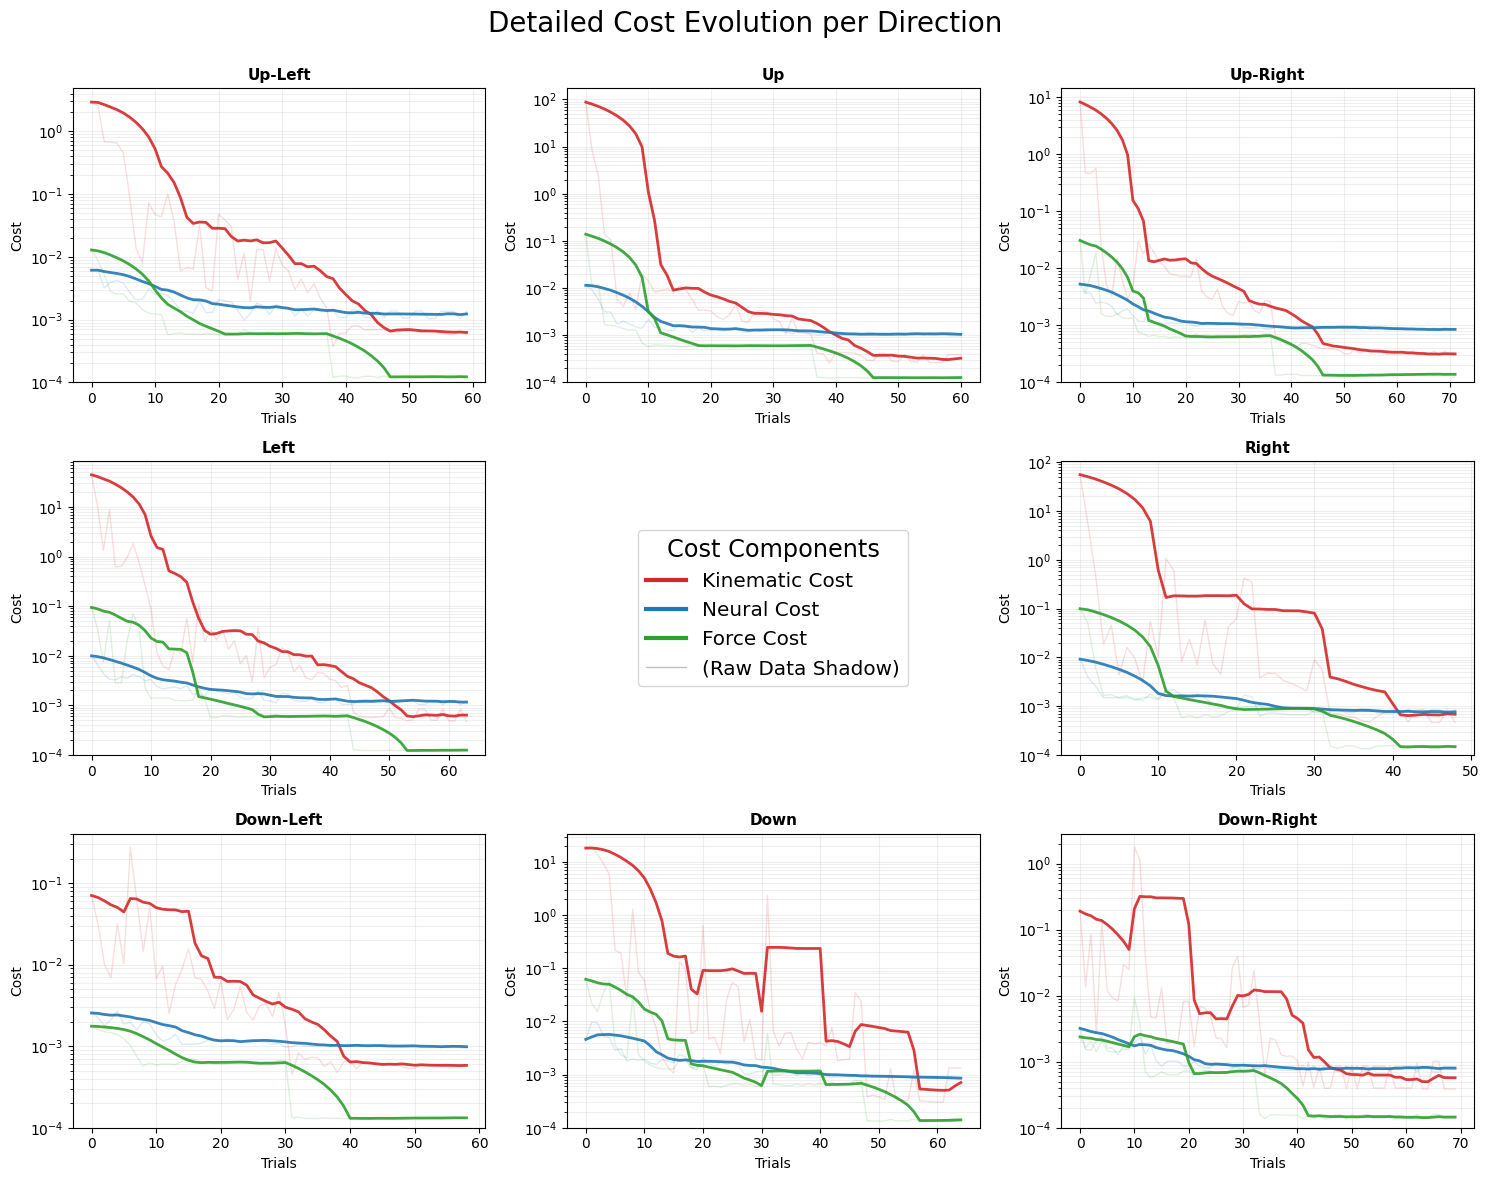

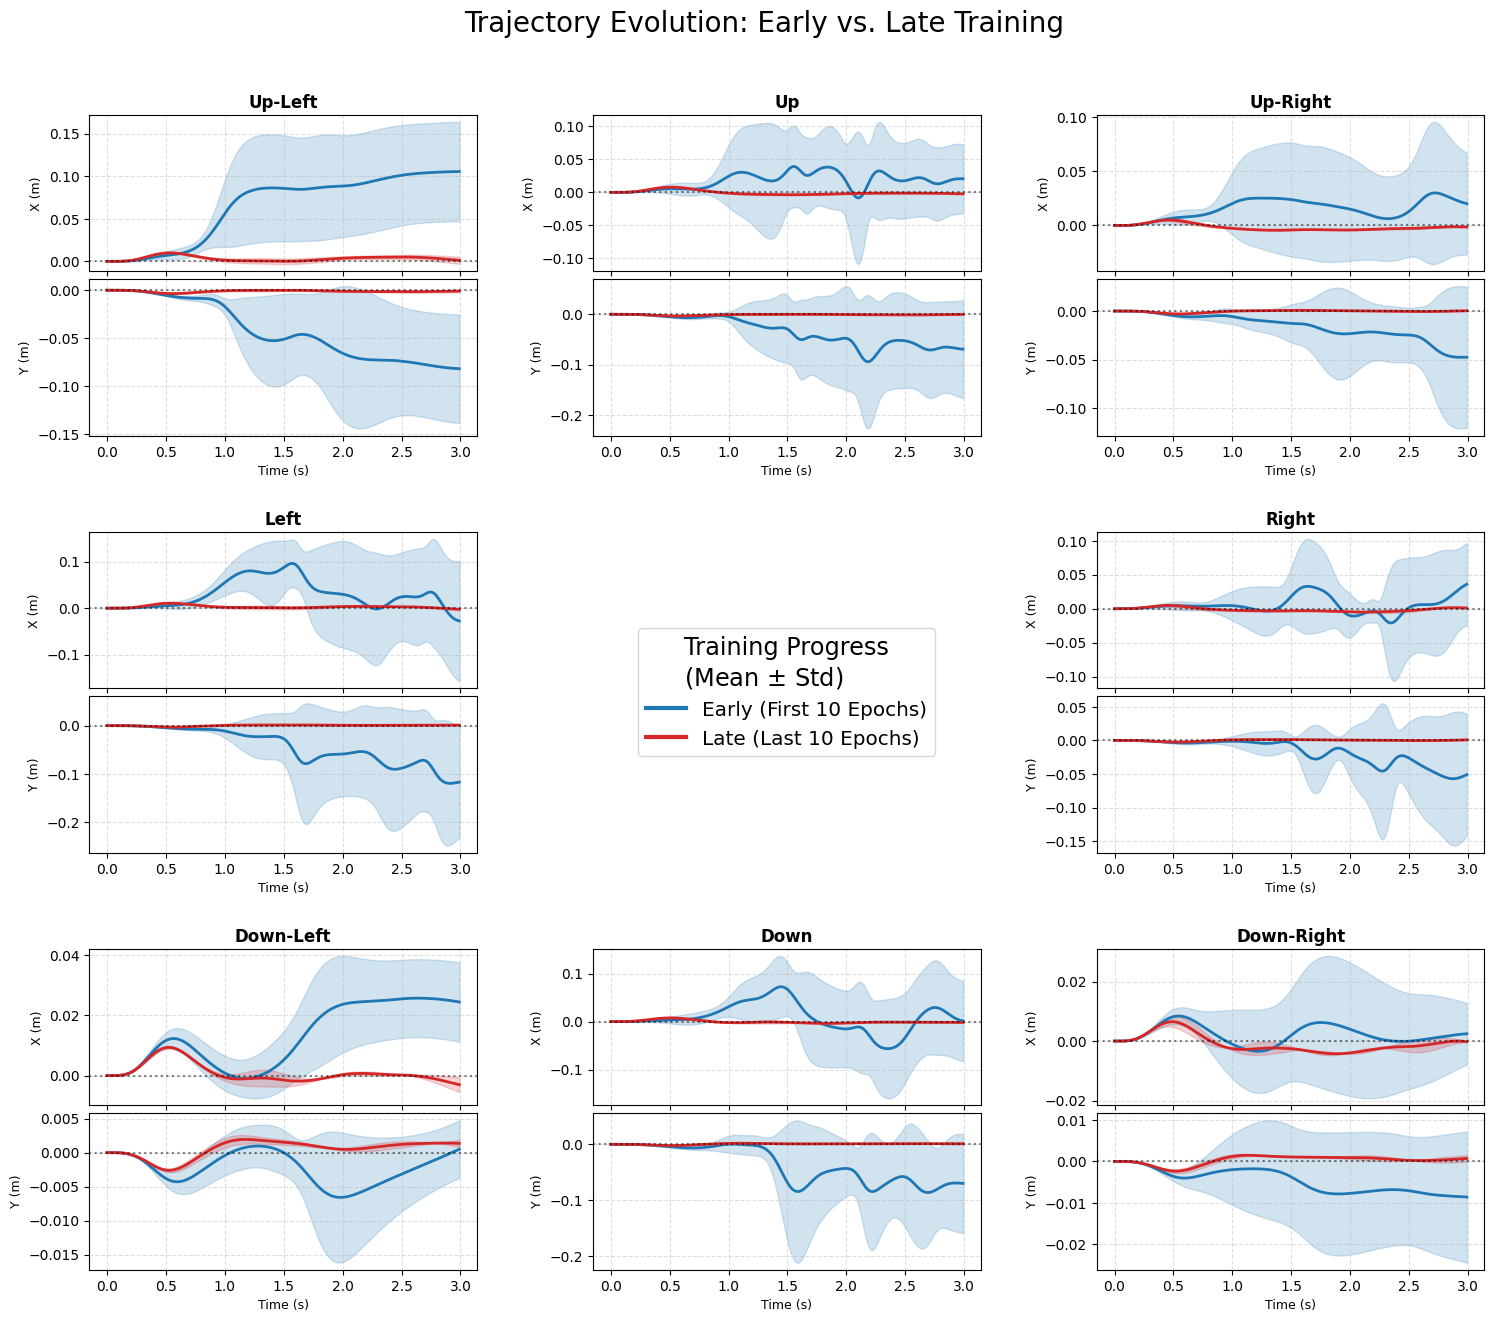

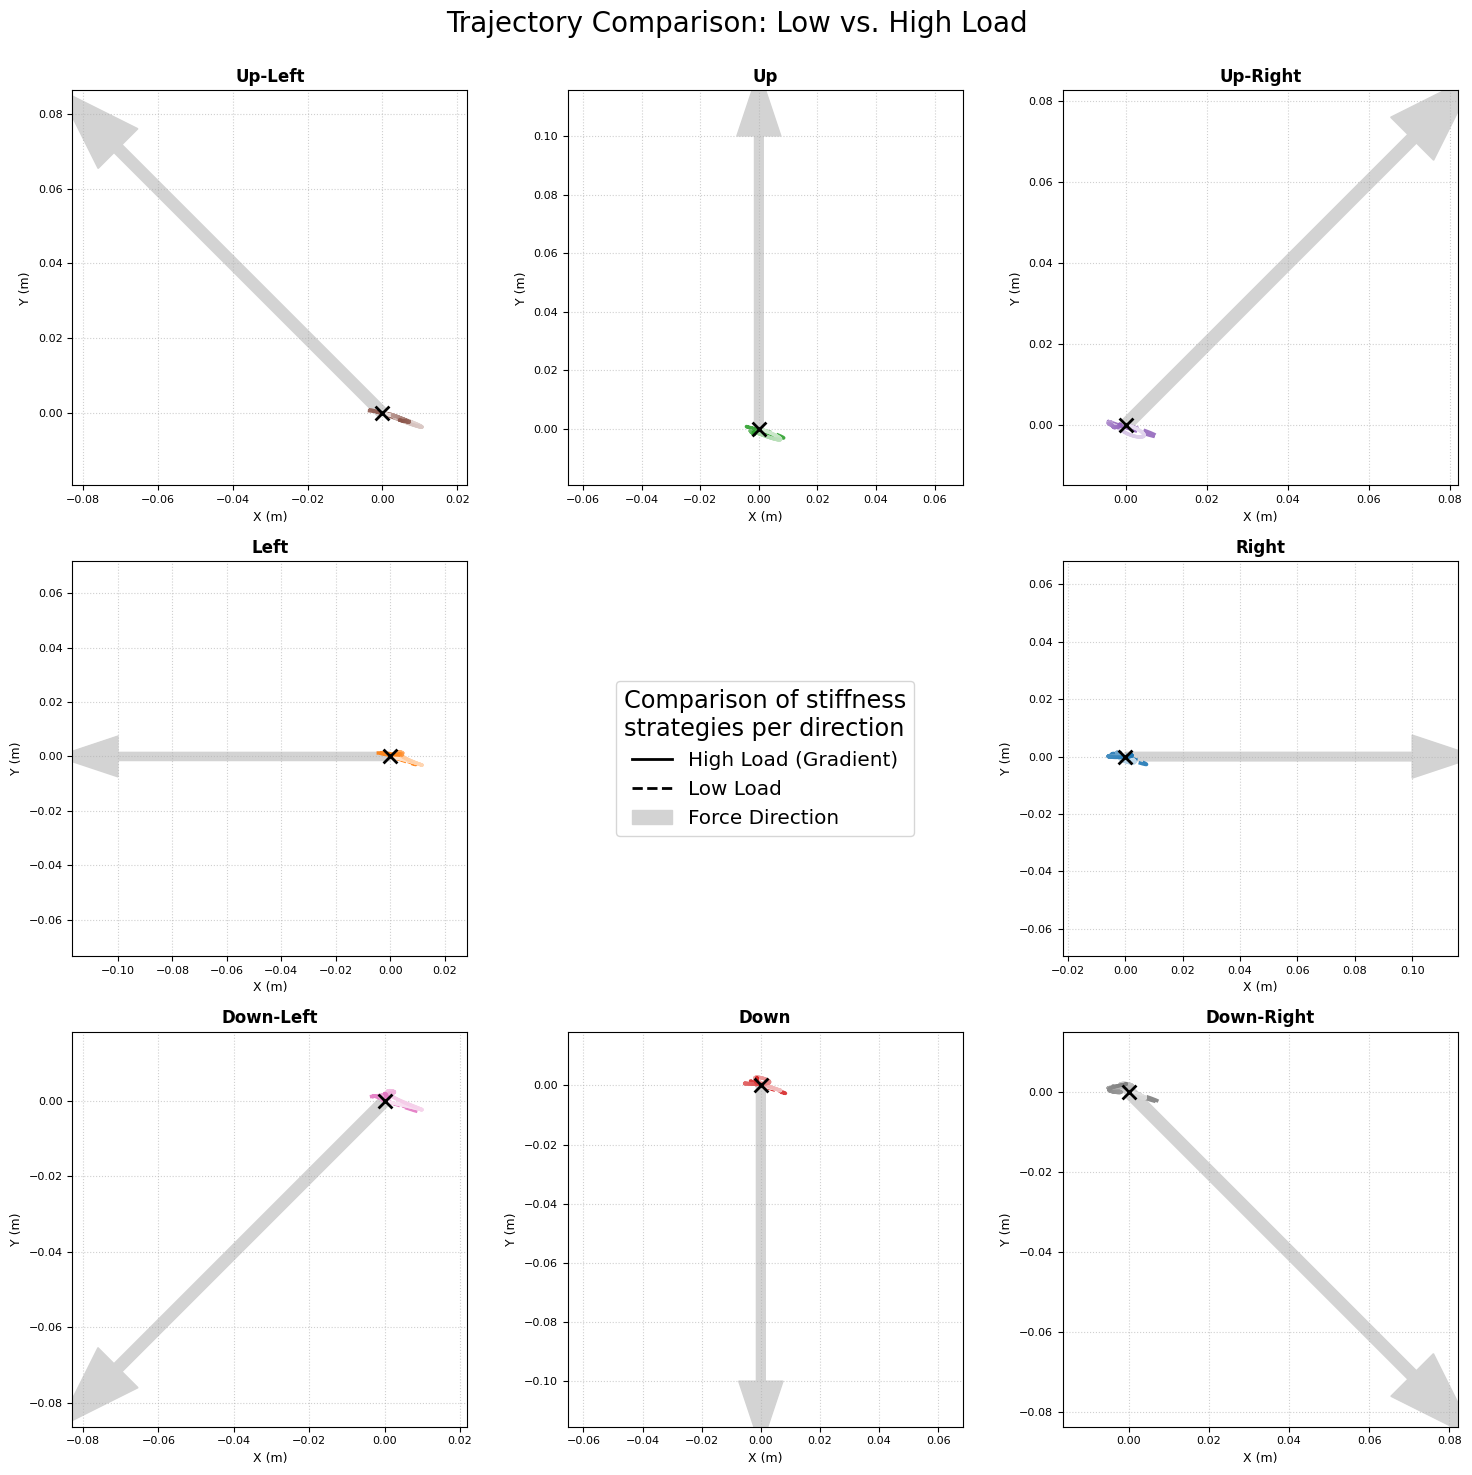

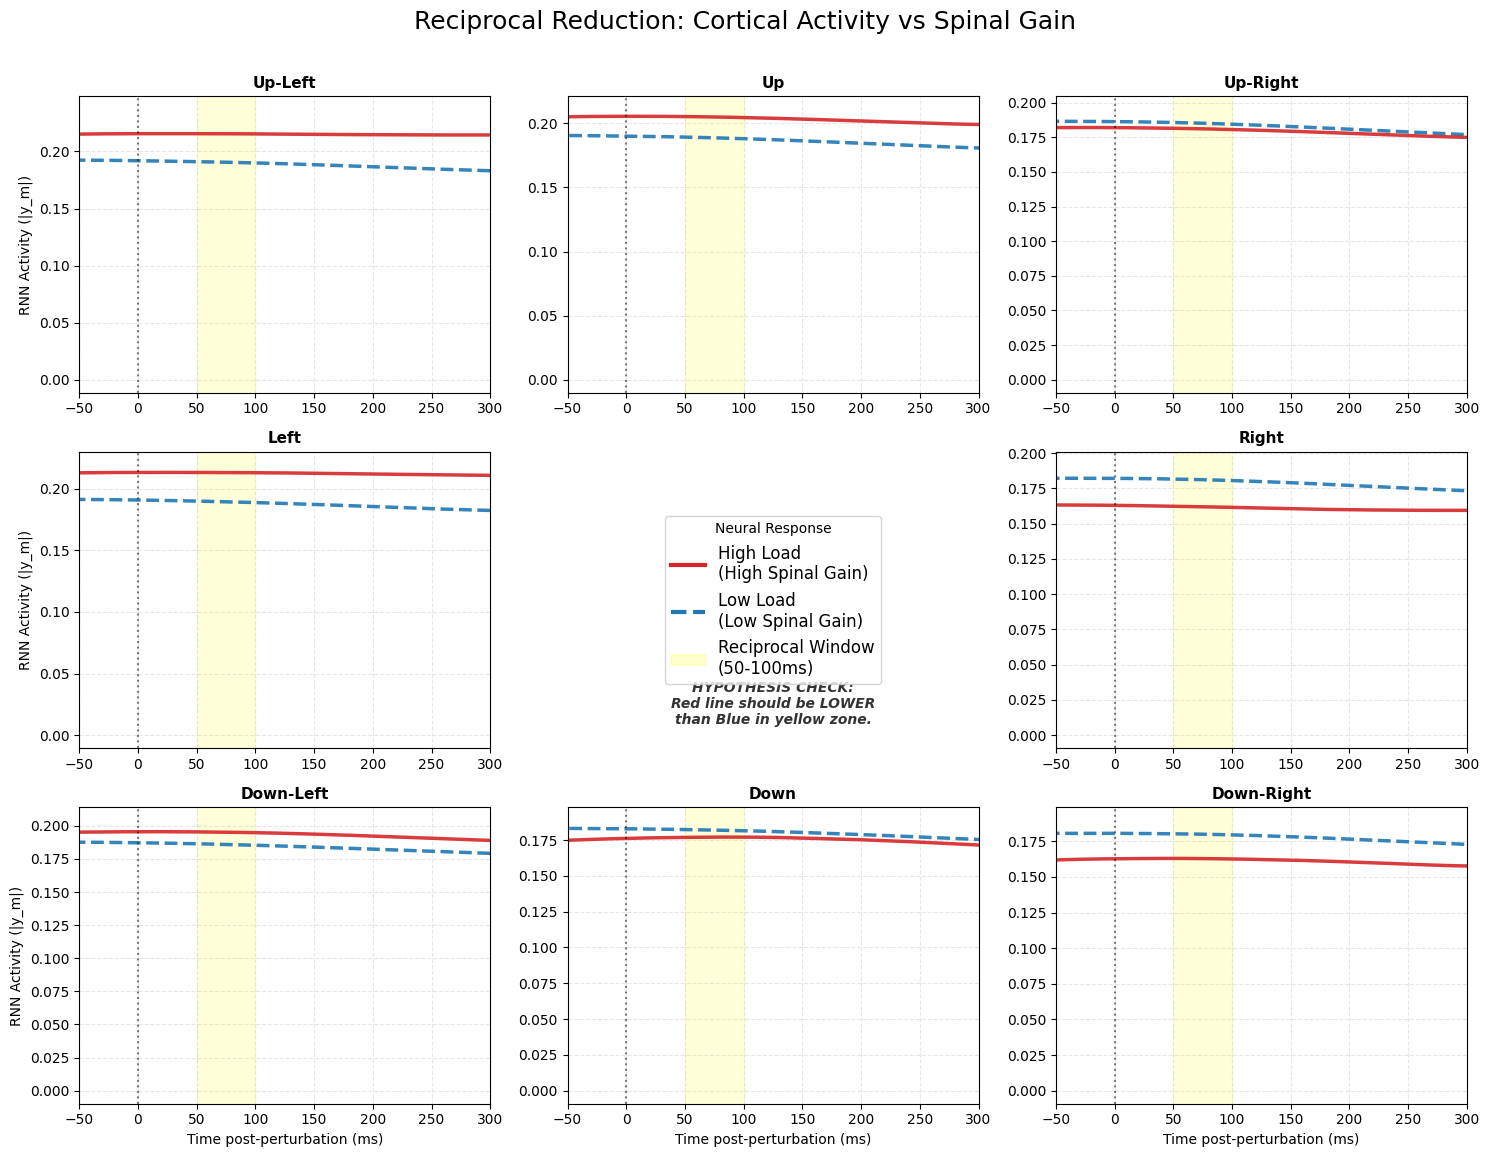

In [157]:
plot_detailed_cost_history(target_results)
plot_trajectory_evolution_grid_xy(epoch_qpos_over_time, epoch_metadata)
plot_detailed_trajectory_comparison(epoch_metadata, epoch_qpos_over_time, perturbation_directions)
plot_neural_activity_comparison(epoch_metadata, epoch_neural_activity, Tp_step)

---

# Biomechanical Control Under Perturbation - Analysis of Results

This simulation trained a neural controller to stabilize a two-link musculoskeletal arm against unexpected external loads. The results demonstrate the emergence of a biologically plausible **impedance control** strategy, characterized by a distinct trade-off between stiffness and energy efficiency.

### 1. The "Yield-and-Stabilize" Strategy (Damped Drift)

The gradient trajectories (solid lines in the grid plot) reveal that the arm does not rigidly hold its position, nor does it snap back to the center after being hit. Instead, it exhibits a controlled yielding behavior.

* **Mechanism:** The perturbation is applied as a step force. The arm's intrinsic stiffness is insufficient to resist this load instantly ($F_{ext} > K \cdot \Delta x$).
* **The Drift:** Initially, the arm drifts rapidly away from the center along the direction of the force (the light-colored start of the line).
* **The Stabilization:** As the neural controller reacts and muscle tension builds, the arm decelerates and settles into a new equilibrium point (the dark end of the line).
* **Result:** Rather than a "hook" shape (drift and return), we observe a **damped drift**. The controller effectively acts as a brake, preventing the arm from flailing wildly but stopping short of pulling it all the way back.

### 2. Evolution of Competence (Early vs. Late)

The **Trajectory Evolution (Mean $\pm$ Std)** plots reveal how the policy matures over training.

* **Early Epochs (Blue):** The agent exhibits high variability (wide shaded regions) and large excursions. The arm often continues to drift significantly further, indicating a lack of effective stiffness.
* **Late Epochs (Red):** The variance bands tighten dramatically. The agent has learned a consistent, repeatable strategy to "catch" the weight. The trajectories are shorter and strictly bounded, confirming that the **Kinematic Cost** reduction seen in the cost plots corresponds to a real-world improvement in stability.

### 3. The Accuracy-Effort Trade-off (Steady-State Error)

A critical observation from the final plots is that the arm exhibits **Steady-State Error**—it settles away from the target $(0,0)$ at the end of the trial.

* **The "Lazy" Agent Hypothesis:** The loss function penalizes both **Position Error** (Kinematic Cost) and **Muscle Effort** (Neural/Force Cost).
* **The Equilibrium:** To pull the arm back to $(0,0)$ against a high load requires massive, continuous muscle activation. The agent has learned that it is "cheaper" to let the arm drift to a point where the **passive elastic tension** of the stretched muscles helps balance the load.
* **Interpretation:** The agent prioritizes **energy efficiency** over **perfect accuracy**. It minimizes the drift enough to prevent failure (extreme error) but avoids the high metabolic cost required for perfect correction.

### 4. Biomechanical Asymmetry

The plots reveal that the arm does not handle all directions equally, reflecting the underlying geometry of the musculoskeletal model.

* **Up-Left vs. Up-Right:** The "Up-Left" trajectory is noticeably tighter than "Up-Right." This is likely due to the **Moment Arm Matrix ($M_m$)** at the posture $\theta_s=35^\circ, \theta_e=90^\circ$. Flexion mechanics are generally more mechanically advantageous in this workspace, whereas extending against a load (Up-Right) involves complex synergies that result in larger displacements.

### 5. Conclusion

The trained policy successfully solves the stabilization task by learning a robust **Impedance Control** law. It transitions from a "floppy" initial state to a "stiff" controller that acts as a damper. The residual steady-state error highlights a biological reality: the motor system optimizes for a compromise between task performance (error) and metabolic cost (effort), rather than absolute kinematic perfection.